In [3]:
import numpy as np
import random
import pandas as pd
import torch
import normflows as nf
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import norm
from scipy.stats import multivariate_normal
from tqdm import tqdm

np.random.seed(0)
I = 5
sigma = 4
tau = 1
gamma = 20
thetas = np.random.normal(gamma ,tau, I)
Y = np.random.normal(thetas,sigma)

In [5]:
# :::::::::::::::::::::::::::::::::::
# Function generate CBC samples
# :::::::::::::::::::::::::::::::::::
def CBC_sample_generator(num_samples = 1):
    samples = np.random.normal(loc=Y, scale=sigma, size=(num_samples, I))
    column_names = [f"Group{i+1}" for i in range(I)]
    return pd.DataFrame(samples, columns=column_names)

# :::::::::::::::::::::::::::::::::::
# True CBC pdf values
# :::::::::::::::::::::::::::::::::::
def CBC_density(theta):
    """ theta should be a vector of size 3 or a dataframe with 3 columns """
    return norm.pdf(theta,loc = Y, scale = sigma).tolist()

## Stage 1: Finding the density of the sampler using CBC samples (Forward KL)

100%|██████████| 1000/1000 [00:01<00:00, 565.20it/s]


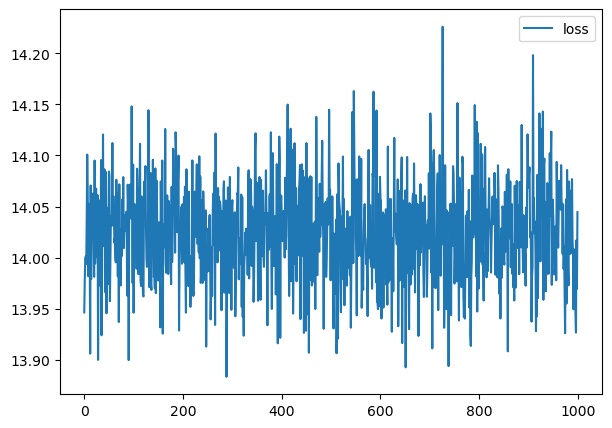

In [6]:
torch.manual_seed(0)

latent_size = I
K = 2 # Number of Layers
# Flow Structure:
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]


q0 = nf.distributions.DiagGaussian(I) # Base Distribution
nfm = nf.NormalizingFlow(q0=q0, flows=flows) # NF Model Setup

device = torch.device('cpu')
nfm = nfm.to(device)
nfm = nfm.float()

max_iter = 1000 # Number of training iterations
num_samples = 1000 # Batch size
optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-4, weight_decay=1e-6)
loss_hist = np.array([])

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm.forward_kld(torch.tensor(CBC_sample_generator(num_samples).values, dtype=torch.float32))
    
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

plt.figure(figsize=(7, 5))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

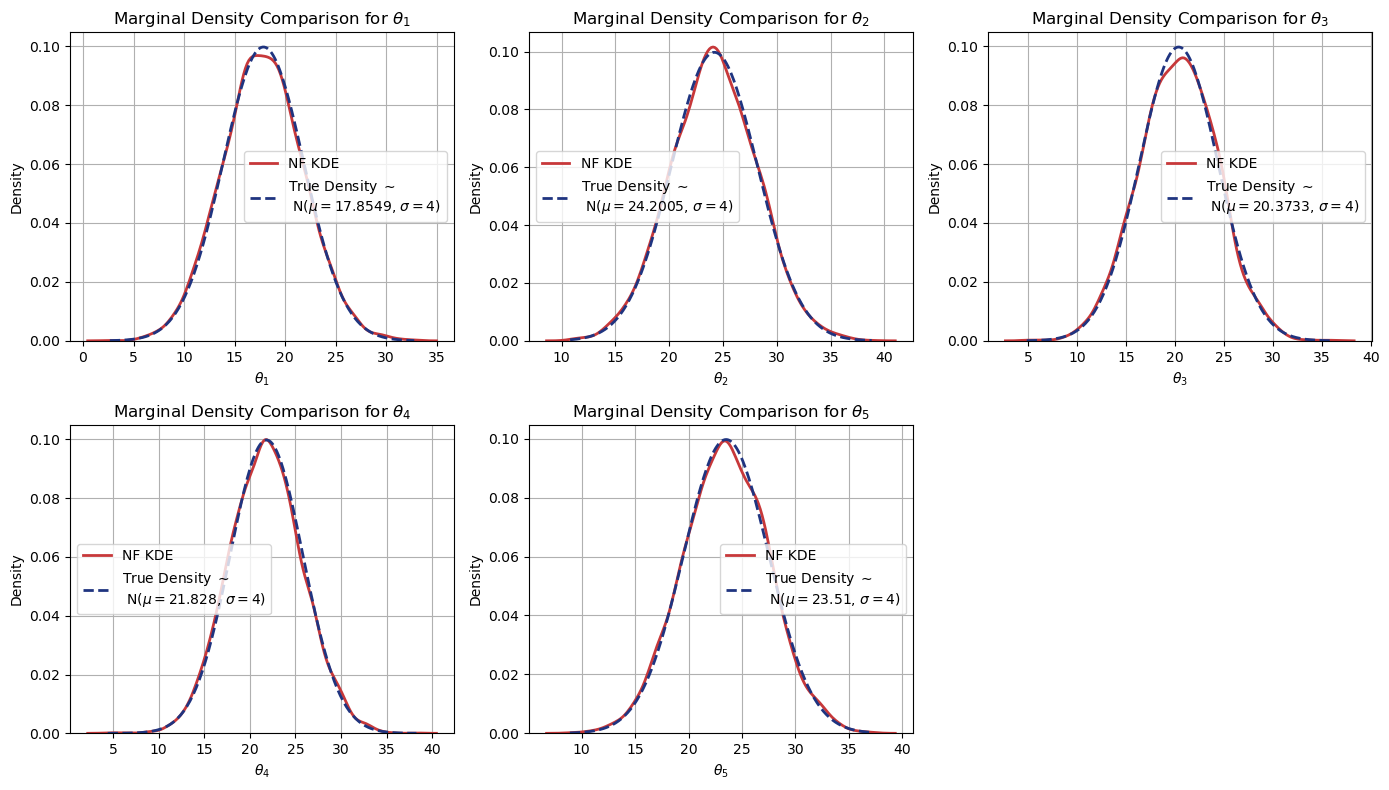

In [13]:
random.seed(0)
torch.manual_seed(0)

z, log_prob = nfm.sample(5000)
prob = torch.exp(log_prob)
z = z.detach().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(I):
    ax = axes[i]
    
    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')
    
    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=Y[i], scale=sigma)
    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label=f'True Density $\\sim$ \n N($\\mu={np.round(Y[i],4)}$, $\\sigma={sigma}$)')
    
    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Marginal Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)
axes[-1].axis('off')

plt.tight_layout()
plt.show()


In [14]:
# :::::::::::::::::::::::::::::::::::
# Summary Statistics - Mean and Standard Deviation Comparisons
# :::::::::::::::::::::::::::::::::::
for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD of the NF Generated Samples (dim {i+1}): {np.round(np.std(z[:,i]),4)} vs Sigma = ",sigma)
    print(f"Mean of NF Generated Samples (dim = {i+1}) {np.round(np.mean(z[:,i]),4)} vs True Y = " ,Y[i])
    print("----------------------------")

Theta 1 
 ----------------------------
SD of the NF Generated Samples (dim 1): 4.013599872589111 vs Sigma =  4
Mean of NF Generated Samples (dim = 1) 17.816499710083008 vs True Y =  17.85494082646202
----------------------------
Theta 2 
 ----------------------------
SD of the NF Generated Samples (dim 2): 4.0065999031066895 vs Sigma =  4
Mean of NF Generated Samples (dim = 2) 24.179899215698242 vs True Y =  24.20051087846958
----------------------------
Theta 3 
 ----------------------------
SD of the NF Generated Samples (dim 3): 3.9869000911712646 vs Sigma =  4
Mean of NF Generated Samples (dim = 3) 20.3435001373291 vs True Y =  20.373309150914945
----------------------------
Theta 4 
 ----------------------------
SD of the NF Generated Samples (dim 4): 4.0183000564575195 vs Sigma =  4
Mean of NF Generated Samples (dim = 4) 21.762300491333008 vs True Y =  21.82801779202723
----------------------------
Theta 5 
 ----------------------------
SD of the NF Generated Samples (dim 5): 3.9

In [15]:
# :::::::::::::::::::::::::::::::::::
# Density Error
# :::::::::::::::::::::::::::::::::::
normal_densities = np.array([
    norm.pdf(z[:, j], loc=Y[j], scale=sigma) for j in range(I)])
product_densities = np.prod(normal_densities, axis=0)
mean_difference = torch.mean(prob - torch.tensor(product_densities, dtype=prob.dtype))
mean_abs_difference = torch.mean(abs(prob - torch.tensor(product_densities, dtype=prob.dtype)))
mean_sqr_difference = np.mean(np.power((prob - torch.tensor(product_densities, dtype=prob.dtype)).detach().numpy(),2))
print("Mean Error :", mean_difference.detach().numpy())
print("Mean Absolute Error :", mean_abs_difference.detach().numpy())
print("Mean Square Error :", mean_sqr_difference)



Mean Error : 2.0047077e-09
Mean Absolute Error : 8.685327e-09
Mean Square Error : 1.7205482e-16


In [16]:
# :::::::::::::::::::::::::::::::::::
# KS Test Results
# :::::::::::::::::::::::::::::::::::
from scipy import stats
np.random.seed(0)
random.seed(0)
torch.manual_seed(0)
true_samples = CBC_sample_generator(2000)
z, log_q = nfm.sample(2000)

z = z.detach().cpu().numpy() 
for i in range(I):
    nf_sample1 = z[:,i]
    true_sample2 = true_samples.iloc[:,i]
    print(f"KS Test: dim {i+1} \n ---------------------")
    print(stats.kstest(nf_sample1, true_sample2))
    print("---------------------")

KS Test: dim 1 
 ---------------------
KstestResult(statistic=np.float64(0.0275), pvalue=np.float64(0.43609338214006377), statistic_location=np.float64(14.89147400964573), statistic_sign=np.int8(-1))
---------------------
KS Test: dim 2 
 ---------------------
KstestResult(statistic=np.float64(0.0285), pvalue=np.float64(0.3910873897562125), statistic_location=np.float64(21.48933219909668), statistic_sign=np.int8(1))
---------------------
KS Test: dim 3 
 ---------------------
KstestResult(statistic=np.float64(0.039), pvalue=np.float64(0.0954673206906231), statistic_location=np.float64(21.608314118261397), statistic_sign=np.int8(-1))
---------------------
KS Test: dim 4 
 ---------------------
KstestResult(statistic=np.float64(0.0155), pvalue=np.float64(0.9699601425241099), statistic_location=np.float64(20.639065341809893), statistic_sign=np.int8(-1))
---------------------
KS Test: dim 5 
 ---------------------
KstestResult(statistic=np.float64(0.033), pvalue=np.float64(0.22624166055654

## Stage 2: Posterior distribution - Reverse KL Model
Target Distribution
$$P(\theta ,\gamma \mid Y) \propto P(\gamma) \prod_{i=1}^I P(\theta_i\mid \gamma,\tau^2) P(Y_i\mid\theta_i)$$
$P(\theta\mid \gamma)$ is available and follows $N(\gamma,\tau^2)$. $P(Y|\theta)$ is the CBC function that we can sample from. In step 1, an estimate of this density is available which we can use to evaluate the density of the target distribution. 

To plot the final results we require $P(\theta \mid Y)$ which would be:
$$\int P(\gamma) \prod_{i=1}^I P(\theta_i\mid \gamma,\tau^2) P(Y_i\mid\theta_i) d\gamma$$
which simplifies to:
$$\theta \mid Y \propto \exp\left( -\frac{1}{2} \sum \theta_i^2 (\frac{1}{\sigma^2} + \frac{1}{\tau^2} - \frac{1}{J\tau^2}) +
\sum \frac{Y_i\theta_i}{\sigma^2} + \frac{1}{J\tau^2}\sum \sum_{i \neq j}\theta_i \theta_j
\right) $$
$$\Rightarrow \Sigma^{-1} = \begin{bmatrix}
\frac{1}{\sigma^2} + \frac{1}{\tau^2} - \frac{1}{J\tau^2} & -\frac{1}{J\tau^2} & \cdots & -\frac{1}{J\tau^2} \\
-\frac{1}{J\tau^2} & \frac{1}{\sigma^2} + \frac{1}{\tau^2} - \frac{1}{J\tau^2}& \cdots & -\frac{1}{J\tau^2} \\
& \vdots&  \\
-\frac{1}{J\tau^2} & \cdots & -\frac{1}{J\tau^2} & \frac{1}{\sigma^2} + \frac{1}{\tau^2} - \frac{1}{J\tau^2}
\end{bmatrix} = (\frac{1}{\sigma^2} + \frac{1}{\tau^2}) I - \frac{1}{J\tau^2} 1_J1_J^T$$
Using Sherman-Morrison formula to invert $\Sigma^{-1}$, we get:
$$\Sigma = (\frac{\sigma^2\tau^2}{\tau^2 + \sigma^2}) I + \left(\frac{\sigma^4}{J(\sigma^2+ \tau^2)}\right)1_J1_J^T$$
Also, 
$$\mu_i = \frac{\sigma^2 \bar{Y} + \tau^2 Y_i}{\sigma^2 + \tau^2}$$

This means that:
$$\theta_i \mid Y \sim N(\mu_i, \frac{\sigma^2\tau^2}{\tau^2 + \sigma^2} + \frac{\sigma^4}{J(\sigma^2+ \tau^2)})$$

---------------------------------------------------------

Similarly:

$$\gamma \mid Y \sim N(\bar{Y}, \frac{\sigma^2 + \tau^2}{J})$$

100%|██████████| 30000/30000 [03:36<00:00, 138.74it/s]


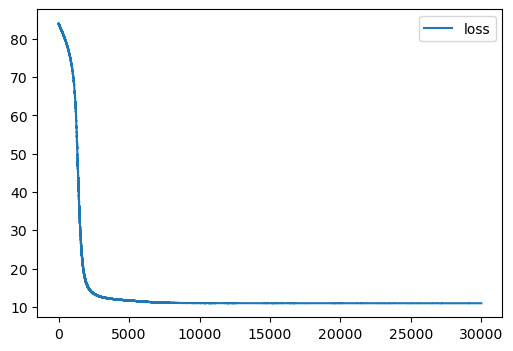

In [17]:
torch.manual_seed(0)

# Fixing the parameters of stage 1 model
nfm = nfm.to(device).float().eval()
for p in nfm.parameters():
        p.requires_grad_(False)

# Defining flow layers
K = 6
latent_size = I + 1
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]


q0_new = nf.distributions.DiagGaussian(I+1) # Base distribution
nfm2 = nf.NormalizingFlow(q0=q0_new, flows=flows) # NF model

device = torch.device('cpu')
nfm2 = nfm2.to(device)
nfm2 = nfm2.float()

# Target distribution
def unnormalized_log_prob(x):
    """Computes log of target density (up to normalizing constant)."""

    theta_value = x[:, :I]  # First I values are thetas
    gamma_value = x[:, I].unsqueeze(-1)  # The (I+1)th value is gamma
    
    log_p_nfm = nfm.log_prob(theta_value)
    log_p_normal = torch.distributions.Normal(gamma_value, tau).log_prob(theta_value).sum(dim=-1)
    return log_p_nfm + log_p_normal 

with torch.no_grad(): # Stablizing the ACTNORM layer
    _ = nfm2.sample(5000)
    
# Training Setup
max_iter = 30000
num_samples0 = 2000
optimizer = torch.optim.Adam(nfm2.parameters(), lr=5e-5, weight_decay=1e-6)
loss_hist = np.array([])

for it in tqdm(range(max_iter)):
    num_samples = min(num_samples0 + it // 100, 7000)

    optimizer.zero_grad()
    # Sample from Base Distribution q0
    z0, log_q0 = q0_new(num_samples)
    # Pass through the Normalizing Flow
    z_samples, sum_log_det_J = nfm2.forward_and_log_det(z0)
    # Debugging Check
    if torch.isnan(z_samples).any():
        print(f"⚠️ NaN detected in z_samples at iteration {it}")
        continue  # Skip iteration if NaN appears
    # Compute unnormalized log density at sampled points
    log_p_target = unnormalized_log_prob(z_samples)
    # Compute Reverse KL loss (Expectation w.r.t. p^*)
    loss = torch.mean(log_q0 - log_p_target - sum_log_det_J)

    if torch.isnan(loss) or torch.isinf(loss):
        print(f"⚠️ NaN or Inf detected in loss at iteration {it}")
        continue 
    else:
        loss.backward()
        optimizer.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


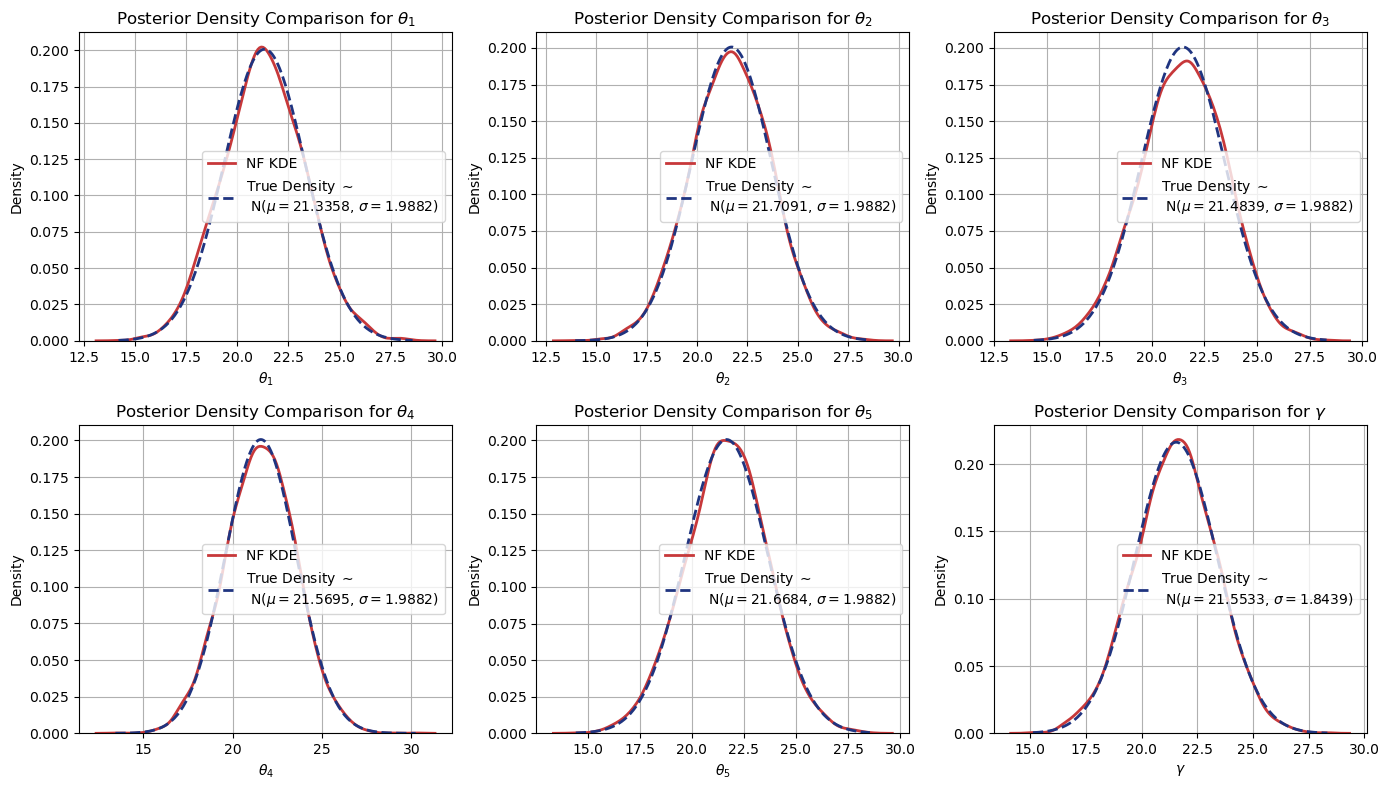

In [20]:
random.seed(123)
torch.manual_seed(123)
np.random.seed(123)

z, _ = nfm2.sample(5000)
z = z.detach().cpu().numpy()

df_z = pd.DataFrame(z)
df_z.columns = [f"dim_{i+1}" for i in range(z.shape[1])]
df_z.to_csv("nf_samples_2.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

mean_posterior = []
var_posterior = ((sigma**2) * (tau**2))/(sigma**2+tau**2) + sigma**4/(I*(sigma**2+tau**2))
sd_posterior = np.sqrt(var_posterior)

for i in range(I):
    ax = axes[i]

    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')

    mean_i = ((sigma**2)*np.mean(Y)+ (tau**2)*Y[i])/(sigma**2+tau**2)
    mean_posterior.append(mean_i)

    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=mean_i, scale=sd_posterior)

    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label=f'True Density $\\sim$ \n N($\\mu={np.round(mean_i,4)}$, $\\sigma={np.round(sd_posterior,4)}$)')

    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Posterior Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)

gamma_mean = np.mean(Y)
gamma_sd = np.sqrt((sigma**2+tau**2)/I)

ax = axes[I]
sns.kdeplot(z[:, I], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')

x_vals = np.linspace(z[:, I].min(), z[:, I].max(), 200)
normal_density = norm.pdf(x_vals, loc=gamma_mean, scale=gamma_sd)

ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
        label=f'True Density $\\sim$ \n N($\\mu={np.round(gamma_mean,4)}$, $\\sigma={np.round(gamma_sd,4)}$)')

ax.set_xlabel(r'$\gamma$')
ax.set_ylabel("Density")
ax.set_title(r"Posterior Density Comparison for $\gamma$")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [21]:
# Summary Statistics
# -----------------------------
for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD:  NF Estimate = {np.round(np.std(z[:,i]),4)} vs True SD = ",sd_posterior)
    print(f"Mean:  NF Estimate = {np.round(np.mean(z[:,i]),4)} vs True Mean = " ,mean_posterior[i])
    print("----------------------------")
print(f"Gamma \n ----------------------------")
print(f"SD: NF Estimate = : {np.round(np.std(z[:,I]),4)} vs True SD = ",gamma_sd)
print(f"Mean: NF Estimate = {np.round(np.mean(z[:,I]),4)} vs True Mean = " ,gamma_mean)
print("----------------------------")

Theta 1 
 ----------------------------
SD:  NF Estimate = 2.0044000148773193 vs True SD =  1.9882004869908336
Mean:  NF Estimate = 21.309200286865234 vs True Mean =  21.335792876055834
----------------------------
Theta 2 
 ----------------------------
SD:  NF Estimate = 1.9779000282287598 vs True SD =  1.9882004869908336
Mean:  NF Estimate = 21.68199920654297 vs True Mean =  21.70906170264451
----------------------------
Theta 3 
 ----------------------------
SD:  NF Estimate = 2.0025999546051025 vs True SD =  1.9882004869908336
Mean:  NF Estimate = 21.48900032043457 vs True Mean =  21.483932189258947
----------------------------
Theta 4 
 ----------------------------
SD:  NF Estimate = 1.9757000207901 vs True SD =  1.9882004869908336
Mean:  NF Estimate = 21.5625 vs True Mean =  21.569503285794966
----------------------------
Theta 5 
 ----------------------------
SD:  NF Estimate = 1.9697999954223633 vs True SD =  1.9882004869908336
Mean:  NF Estimate = 21.666900634765625 vs True Mea

## Two Stage FB Sampling


In [22]:
np.random.seed(0)
random.seed(0)

# Stage 1:
T = 5000 # Number of samples per theta
theta_cbc_samples = np.array([np.random.normal(y, sigma, T) for y in Y]) # Software Samples
theta_ts = np.zeros((I, T)) 
gamma_ts = np.zeros(T)
for i in range(I):
    theta_ts[i, 0] = random.choice(theta_cbc_samples[i])

# Stage 2: MCMC Sampling Process
for t in range(1, T):
    # Draw gamma from Normal(Mean of theta_ts[t-1], tau^2 / I)
    gamma_ts[t] = np.random.normal(loc=np.mean(theta_ts[:, t-1]), scale=tau / np.sqrt(I))

    # Update each theta_i
    for i in range(I):
        # Propose new theta_i sample from the CBC samples (recycled)
        theta_prop = random.choice(theta_cbc_samples[i])
        # Compute Metropolis-Hastings acceptance ratio
        num = norm.pdf(theta_prop, gamma_ts[t], tau)
        den = norm.pdf(theta_ts[i, t-1], gamma_ts[t], tau)
        R_i = num / den
        # Accept/reject step
        if np.random.uniform(0, 1) < min(1, R_i):
            theta_ts[i, t] = theta_prop
        else:
            theta_ts[i, t] = theta_ts[i, t-1]

# Store the results
two_stage_FB_results = pd.DataFrame(theta_ts.T, columns=[f"theta_{i+1}" for i in range(I)])
two_stage_FB_results["gamma"] = gamma_ts 
two_stage_FB_results = two_stage_FB_results.iloc[1:]
# Save to CSV
two_stage_FB_results.to_csv("two_stage_FB_simple_hierarchical_model_flat_prior.csv", index=False)

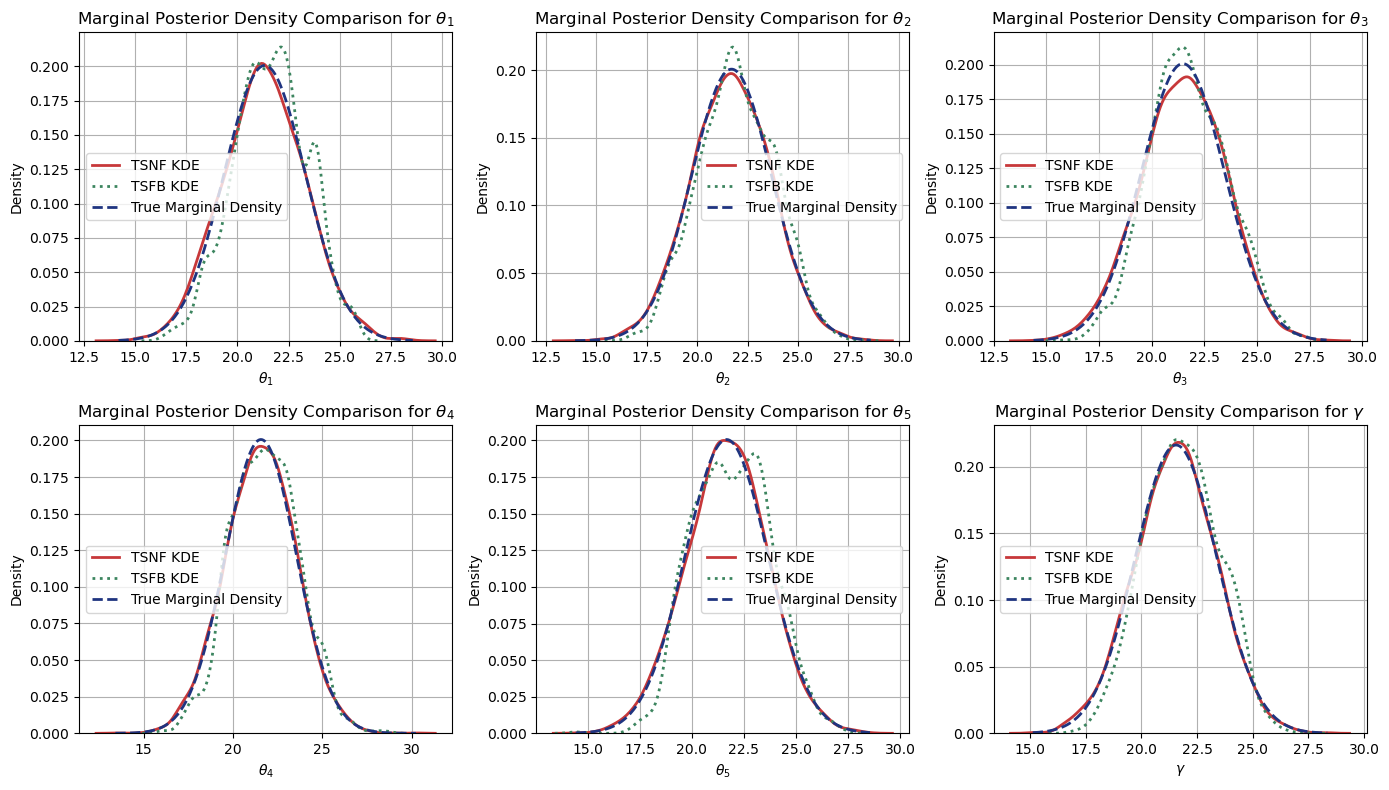

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(I):
    ax = axes[i]

    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax,
                label='TSNF KDE')
    sns.kdeplot(two_stage_FB_results.iloc[:, i], color='#3C855F',
                linestyle='dotted', linewidth=2, ax=ax,
                label='TSFB KDE')

    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=mean_posterior[i], scale=sd_posterior)
    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label='True Marginal Density')

    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Marginal Posterior Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)

ax = axes[I]

sns.kdeplot(z[:, I], color='#C7383A', linewidth=2, ax=ax,
            label='TSNF KDE')
sns.kdeplot(two_stage_FB_results.iloc[:, I], color='#3C855F',
            linestyle='dotted', linewidth=2, ax=ax,
            label='TSFB KDE')

x_vals = np.linspace(z[:, I].min(), z[:, I].max(), 200)
normal_density = norm.pdf(x_vals, loc=gamma_mean, scale=gamma_sd)
ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
        label='True Marginal Density')

ax.set_xlabel(r'$\gamma$')
ax.set_ylabel("Density")
ax.set_title(r"Marginal Posterior Density Comparison for $\gamma$")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [24]:
# Errors

for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD Error: TSNF = {np.round(np.std(z[:,i])- sd_posterior,4)} vs. TSFB = {np.round(np.std(two_stage_FB_results.iloc[:,i]) - sd_posterior,4)}")
    print(f"Mean Error: TSNF = {np.round(np.mean(z[:,i])- mean_posterior[i],4)} vs. TTSFB = {np.round(np.mean(two_stage_FB_results.iloc[:,i])-mean_posterior[i],4)}")
    print("----------------------------")

print(f"Gamma \n ----------------------------")
print(f"SD Error: TSNF = {np.round(np.std(z[:,I])- gamma_sd,4)} vs. TSFB = {np.round(np.std(two_stage_FB_results.iloc[:,I]) - gamma_sd,4)}")
print(f"Mean Error: TSNF = {np.round(np.mean(z[:,I])- gamma_mean,4)} vs. TSFB = {np.round(np.mean(two_stage_FB_results.iloc[:,I])-gamma_mean,4)}")
  

Theta 1 
 ----------------------------
SD Error: TSNF = 0.0162 vs. TSFB = -0.2086
Mean Error: TSNF = -0.0265 vs. TTSFB = 0.2878
----------------------------
Theta 2 
 ----------------------------
SD Error: TSNF = -0.0103 vs. TSFB = -0.1067
Mean Error: TSNF = -0.0271 vs. TTSFB = 0.2556
----------------------------
Theta 3 
 ----------------------------
SD Error: TSNF = 0.0144 vs. TSFB = -0.1336
Mean Error: TSNF = 0.0051 vs. TTSFB = 0.26
----------------------------
Theta 4 
 ----------------------------
SD Error: TSNF = -0.0125 vs. TSFB = -0.1089
Mean Error: TSNF = -0.0071 vs. TTSFB = 0.2405
----------------------------
Theta 5 
 ----------------------------
SD Error: TSNF = -0.0184 vs. TSFB = -0.1464
Mean Error: TSNF = -0.0015 vs. TTSFB = 0.2591
----------------------------
Gamma 
 ----------------------------
SD Error: TSNF = -0.0133 vs. TSFB = -0.1793
Mean Error: TSNF = -0.0239 vs. TSFB = 0.2523


## Correlations

In [25]:
covariance_NF = np.cov(z[:,:I], rowvar=False)
covariance_FB = np.cov(two_stage_FB_results.iloc[:,:I], rowvar=False)

theta_cov = sigma**4/(I*(sigma**2+tau**2))
true_cov_matrix = np.full((I, I), theta_cov)  
np.fill_diagonal(true_cov_matrix, var_posterior)

cov_error_NF = (covariance_NF - true_cov_matrix)**2
cov_error_FB = (covariance_FB - true_cov_matrix)**2

# Compute mean errors
mean_error_NF = np.mean(cov_error_NF)
mean_error_FB = np.mean(cov_error_FB)

print("Mean Squared Error of Covariance Matrix ->","TSNF: ",np.round(mean_error_NF,4),", TSFB: ",np.round(mean_error_FB,4))

print("Covariance Matrix Estimates:\n---------------------------------------------")
print("TSNF:\n",pd.DataFrame(covariance_NF, index=range(1, I+1), columns=range(1, I+1)))
print("TSFB:\n",pd.DataFrame(covariance_FB, index=range(1, I+1), columns=range(1, I+1)))
print("True:\n",pd.DataFrame(true_cov_matrix, index=range(1, I+1), columns=range(1, I+1)))

print("Covariance Matrix Error:\n---------------------------------------------")
print("TSNF:\n",pd.DataFrame(cov_error_NF, index=range(1, I+1), columns=range(1, I+1)))
print("TSFB:\n",pd.DataFrame(cov_error_FB, index=range(1, I+1), columns=range(1, I+1)))

Mean Squared Error of Covariance Matrix -> TSNF:  0.0022 , TSFB:  0.3516
Covariance Matrix Estimates:
---------------------------------------------
TSNF:
           1         2         3         4         5
1  4.018568  3.012234  3.070415  3.011127  3.029449
2  3.012234  3.912749  3.019891  2.925268  2.954554
3  3.070415  3.019891  4.011339  3.008716  2.980079
4  3.011127  2.925268  3.008716  3.904192  2.949270
5  3.029449  2.954554  2.980079  2.949270  3.880954
TSFB:
           1         2         3         4         5
1  3.167514  2.315448  2.337228  2.406656  2.286335
2  2.315448  3.540688  2.437776  2.506040  2.421240
3  2.337228  2.437776  3.440268  2.508453  2.428662
4  2.406656  2.506040  2.508453  3.532441  2.496318
5  2.286335  2.421240  2.428662  2.496318  3.393010
True:
           1         2         3         4         5
1  3.952941  3.011765  3.011765  3.011765  3.011765
2  3.011765  3.952941  3.011765  3.011765  3.011765
3  3.011765  3.011765  3.952941  3.011765  3.011765

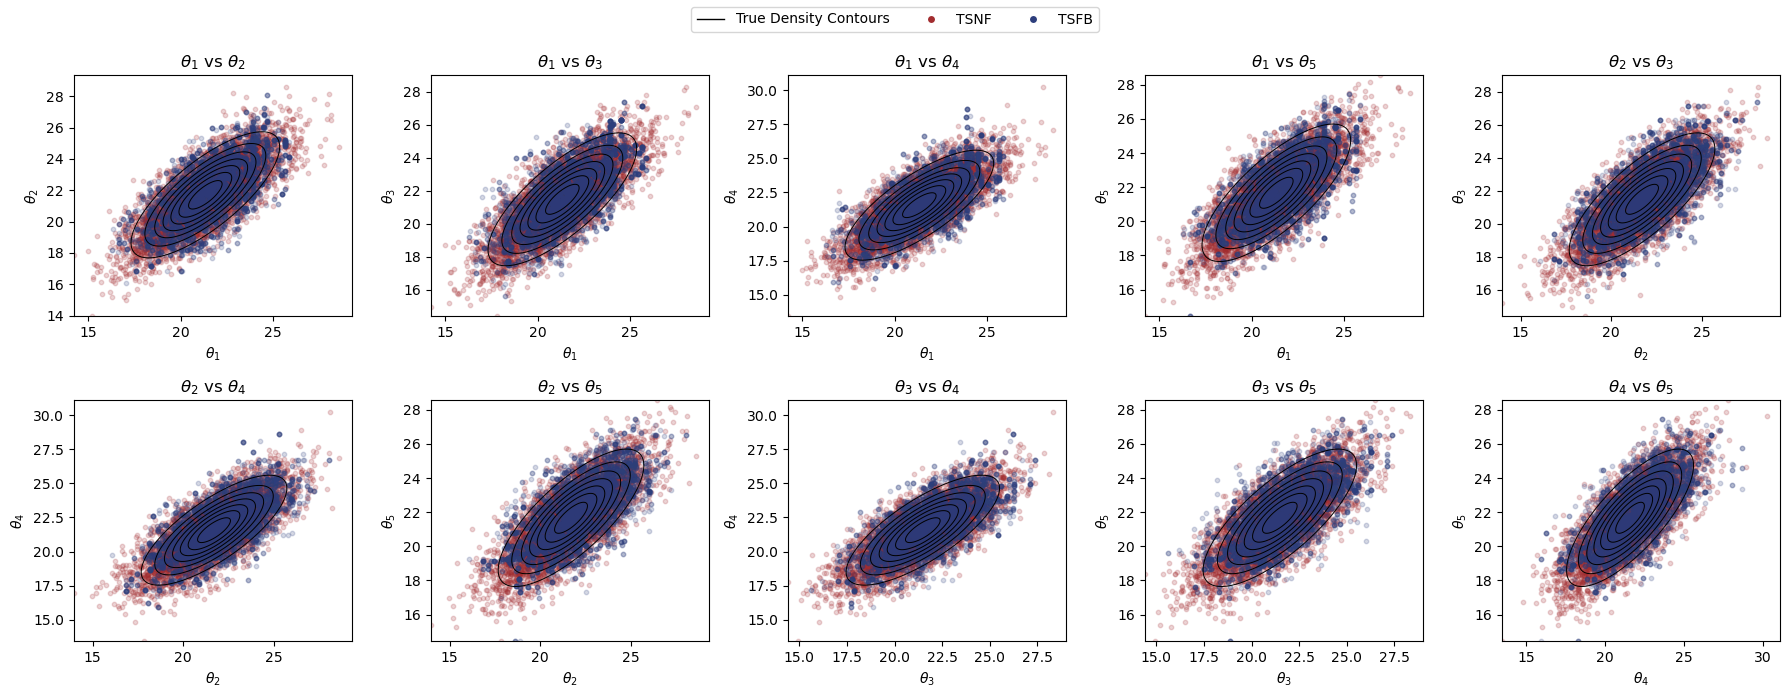

In [26]:
from itertools import combinations

pairs = list(combinations(range(I), 2))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):
    true_cov = sigma**4 / (I * (sigma**2 + tau**2))
    cov_matrix = np.array([[var_posterior, true_cov], [true_cov, var_posterior]])
    mu = np.array([mean_posterior[i], mean_posterior[j]])
    rv = multivariate_normal(mu, cov_matrix)

    NF_samples = z[:, [i, j]]
    FB_samples = two_stage_FB_results.iloc[:, [i, j]].values

    x_min, x_max = min(NF_samples[:, 0].min(), FB_samples[:, 0].min()), max(NF_samples[:, 0].max(), FB_samples[:, 0].max())
    y_min, y_max = min(NF_samples[:, 1].min(), FB_samples[:, 1].min()), max(NF_samples[:, 1].max(), FB_samples[:, 1].max())

    x, y = np.mgrid[x_min:x_max:.01, y_min:y_max:.01]
    pos = np.dstack((x, y))

    ax.contour(x, y, rv.pdf(pos), colors='black', linewidths=0.7)

    ax.scatter(NF_samples[:, 0], NF_samples[:, 1], color='#a22c2f', alpha=0.2, s=10, label='TSNF')
    ax.scatter(FB_samples[:, 0], FB_samples[:, 1], color='#2d3e7c', alpha=0.2, s=10, label='TSFB')

    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel(rf'$\theta_{j+1}$')
    ax.set_title(rf'$\theta_{i+1}$ vs $\theta_{j+1}$')

contour_proxy = mlines.Line2D([], [], color='black', linewidth=1, label="True Density Contours")
point_proxy1 = mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#a22c2f', markersize=6, label='TSNF')
point_proxy2 = mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#2d3e7c', markersize=6, label='TSFB')

fig.legend(handles=[contour_proxy, point_proxy1, point_proxy2], loc='upper center', ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
